In [ ]:
from google.colab import files
import pandas as pd
import io

In [ ]:
uploaded = files.upload()

Saving Titanic-Dataset (3).csv to Titanic-Dataset (3).csv


In [ ]:
import pandas as pd
df = pd.read_csv('/content/Titanic-Dataset (3).csv')

print(df)
print(df.head(10))
print(df.tail(10))
print(df.info())
print(df.describe())
print(df.columns)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

missing_values = df.isnull().sum()
print('--------MISSING VALUE--------')
print(missing_values)

print('--------DATA PREVIEW--------')
print(df.head(5))
print('\n\n')

if 'Cabin' in df.columns:
    df = df.drop(columns=['Cabin'])
else:
    print("Column 'Cabin' not found, skipping drop operation.")

df['Age'] = df['Age'].fillna(value=df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(value=df['Embarked'].mode()[0])

print('--------UPDATED MISSING VALUE--------')
print(df.isnull().sum())

print()

print('--------DATA PREVIEW--------')
print(df.head(5))
print('\n\n')

--------MISSING VALUE--------
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
--------DATA PREVIEW--------
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df = pd.read_csv('/content/Titanic-Dataset (3).csv')

minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

df['Age'] = df['Age'].fillna(df[['Age']].median())
df['Normalized(MinMax)'] = minmax_scaler.fit_transform(df[['Age']])
df['Standardized(Z-Score)'] = standard_scaler.fit_transform(df[['Age']])



print('--------COMPARISON--------')
print(df[['Age', 'Normalized(MinMax)', 'Standardized(Z-Score)']].head())



--------COMPARISON--------
    Age  Normalized(MinMax)  Standardized(Z-Score)
0  22.0            0.271174              -0.530377
1  38.0            0.472229               0.571831
2  26.0            0.321438              -0.254825
3  35.0            0.434531               0.365167
4  35.0            0.434531               0.365167


# **PART 1: Feature Engineering**

In [ ]:
print(df[['SibSp','Parch']].info()) #Checking if there's a missing values and data types

print(df[['SibSp','Parch']].head(10)) #View the first 5 rows.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   SibSp   891 non-null    int64
 1   Parch   891 non-null    int64
dtypes: int64(2)
memory usage: 14.1 KB
None
   SibSp  Parch
0      1      0
1      1      0
2      0      0
3      1      0
4      0      0
5      0      0
6      0      0
7      3      1
8      0      2
9      1      0


In [ ]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1 # Create the FamilySize column

print(df[['SibSp','Parch','FamilySize']].head())

   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1


# **Interpretation:**
*  Passenger 0 is traveling with one or more family members.
*  Passenger 1 is traveling with one or more family members.
*  Passenger 2 is traveling alone.
*  Passenger 3 is traveling with one or more family members.
*  Passenger 4 is traveling alone.

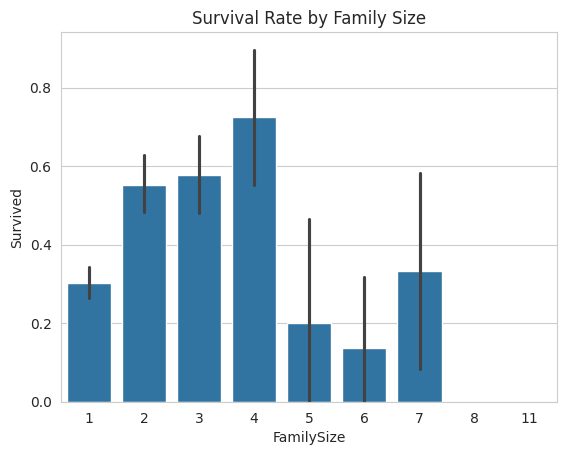

FamilySize
1             537
2             161
3             102
4              29
5              15
6              22
7              12
8               6
11              7
Name: count, dtype: int64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

# Plotting survival rate by family size
sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title('Survival Rate by Family Size')
plt.show()

print(df[['FamilySize']].value_counts().sort_index())

In [ ]:
df['IsAlone'] = 0 # Initialize to 0 (not alone)

df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1 # If FamilySize is 1, set IsAlone to 1

print(df['IsAlone'].value_counts()) # Check the breakdown

IsAlone
1    537
0    354
Name: count, dtype: int64


# **PART 2 : Encoding the "Sex" Feature**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Ensure Sex is encoded: male -> 0, female -> 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Ensure FamilySize is created
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# We use our newly created and encoded features
X = df[['FamilySize', 'Sex', 'Pclass', 'Fare']]
y = df['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 4. Model: RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7174887892376681
Confusion Matrix:
 [[108  26]
 [ 37  52]]


In [ ]:
# Map 'male' to 0 and 'female' to 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# This should now output: array([0, 1]) or array([1, 0])
print(df['Sex'].unique())

# View the numeric transformation
print(df[['Sex']].head(11))

[nan]
    Sex
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
10  NaN
